In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ============================================
# 1. LOAD AND CLEAN DATA (FROM SCRATCH)
# ============================================

print("=" * 60)
print("LOADING AND PREPARING DATA")
print("=" * 60)

# Load the original dataset
df = pd.read_csv('SU.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df['SU_Close'] = df['SU_Close'].ffill()  # Forward fill missing values

# Define the test period (last 30 days)
test_size = 30
full_series = df['SU_Close']
train_series = full_series[:-test_size]
test_series = full_series[-test_size:]

print(f"Data loaded successfully.")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Training series: {len(train_series)} points")
print(f"Test series: {len(test_series)} points")

# ============================================
# 2. LOAD INDIVIDUAL MODEL PREDICTIONS
# ============================================

print("\n" + "=" * 60)
print("LOADING MODEL PREDICTIONS")
print("=" * 60)

# Load predictions from individual models
lstm_results = pd.read_csv('lstm.csv', parse_dates=['Date'], index_col='Date')
xgboost_results = pd.read_csv('xgboost.csv', parse_dates=['Date'], index_col='Date')

# Ensure we have the same test period across files
common_dates = lstm_results.index.intersection(xgboost_results.index).intersection(test_series.index)

lstm_pred = lstm_results.loc[common_dates, 'LSTM_Predicted']
xgboost_pred = xgboost_results.loc[common_dates, 'XGBoost_Predicted']
actual_values = test_series.loc[common_dates]

print(f"Found {len(common_dates)} common prediction days.")
print(f"Date range for ensemble: {common_dates.min().date()} to {common_dates.max().date()}")

# ============================================
# 3. CREATE LSTM-XGBOOST ENSEMBLE (SIMPLE AVERAGE)
# ============================================

print("\n" + "=" * 60)
print("CREATING LSTM-XGBOOST ENSEMBLE MODEL")
print("=" * 60)

# Calculate the simple average (mean) of predictions
ensemble_predictions = (lstm_pred.values + xgboost_pred.values) / 2.0

# Calculate performance metrics
ensemble_rmse = np.sqrt(np.mean((actual_values.values - ensemble_predictions) ** 2))
ensemble_mae = np.mean(np.abs(actual_values.values - ensemble_predictions))

print(f"Ensemble Model Performance:")
print(f"  RMSE: {ensemble_rmse:.2f}")
print(f"  MAE:  {ensemble_mae:.2f}")

# ============================================
# 3.1 CALCULATE METRICS PER BLOCK (5-DAY BLOCKS)
# ============================================

print("\n" + "=" * 60)
print("CALCULATING METRICS PER DATE RANGE (5-DAY BLOCKS)")
print("=" * 60)

# Create a DataFrame with actual and predicted values for easier manipulation
results_df = pd.DataFrame({
    'Actual': actual_values.values,
    'Predicted': ensemble_predictions
}, index=common_dates)

# Sort by date to ensure correct ordering
results_df = results_df.sort_index()

# Determine number of 5-day blocks
n_future_steps_per_block = 5
num_blocks = len(results_df) // n_future_steps_per_block

# Calculate metrics for each block
block_metrics = []

for i in range(num_blocks):
    start_idx = i * n_future_steps_per_block
    end_idx = start_idx + n_future_steps_per_block
    
    if end_idx <= len(results_df):
        block_data = results_df.iloc[start_idx:end_idx]
        block_actual = block_data['Actual'].values
        block_predicted = block_data['Predicted'].values
        
        # Calculate RMSE and MAE for this block
        block_rmse = np.sqrt(np.mean((block_actual - block_predicted) ** 2))
        block_mae = np.mean(np.abs(block_actual - block_predicted))
        
        # Get date range for this block (format: dd/mm - dd/mm)
        start_date = block_data.index[0].strftime('%d/%m')
        end_date = block_data.index[-1].strftime('%d/%m')
        date_range = f"{start_date} -- {end_date}"
        
        block_metrics.append({
            'Date Range': date_range,
            'RMSE': block_rmse,
            'MAE': block_mae
        })

# Create a DataFrame for the block metrics
block_metrics_df = pd.DataFrame(block_metrics)

# Display the table in a formatted way
print("\nBlock Metrics for LSTM-XGBoost Ensemble:")
print("-" * 50)
print(f"{'Date Range':<20} {'RMSE':<10} {'MAE':<10}")
print("-" * 50)
for _, row in block_metrics_df.iterrows():
    print(f"{row['Date Range']:<20} {row['RMSE']:.2f}      {row['MAE']:.2f}")

# If there are remaining days (less than a full block), calculate for them too
remaining_days = len(results_df) % n_future_steps_per_block
if remaining_days > 0:
    remaining_data = results_df.iloc[-remaining_days:]
    remaining_actual = remaining_data['Actual'].values
    remaining_predicted = remaining_data['Predicted'].values
    
    remaining_rmse = np.sqrt(np.mean((remaining_actual - remaining_predicted) ** 2))
    remaining_mae = np.mean(np.abs(remaining_actual - remaining_predicted))
    
    start_date = remaining_data.index[0].strftime('%d/%m')
    end_date = remaining_data.index[-1].strftime('%d/%m')
    date_range = f"{start_date} -- {end_date}"
    
    print(f"{date_range:<20} {remaining_rmse:.2f}      {remaining_mae:.2f}")

print("-" * 50)

# ============================================
# 3.2 CALCULATE CUMULATIVE METRICS FOR 5, 10, 15, 20, 25, 30 DAYS
# ============================================

print("\n" + "=" * 60)
print("CUMULATIVE METRICS FOR DIFFERENT TIME HORIZONS")
print("=" * 60)

# Define the cumulative periods (in days)
periods = [5, 10, 15, 20, 25, 30]

# Initialize a list to store the cumulative metrics
cumulative_metrics = []

# Calculate cumulative metrics for each period
for period in periods:
    if period <= len(results_df):
        # Take the first 'period' days
        period_data = results_df.iloc[:period]
        period_actual = period_data['Actual'].values
        period_predicted = period_data['Predicted'].values
        
        # Calculate RMSE and MAE for this cumulative period
        period_rmse = np.sqrt(np.mean((period_actual - period_predicted) ** 2))
        period_mae = np.mean(np.abs(period_actual - period_predicted))
        
        # Get the date range for this period
        start_date = period_data.index[0].strftime('%d/%m')
        end_date = period_data.index[-1].strftime('%d/%m')
        date_range = f"{start_date} -- {end_date}"
        
        cumulative_metrics.append({
            'Days': period,
            'Date Range': date_range,
            'RMSE': period_rmse,
            'MAE': period_mae
        })

# Create a DataFrame for the cumulative metrics
cumulative_metrics_df = pd.DataFrame(cumulative_metrics)

# Display the table in a formatted way
print("\nCumulative Metrics for LSTM-XGBoost Ensemble:")
print("-" * 60)
print(f"{'Days':<6} {'Date Range':<20} {'RMSE':<10} {'MAE':<10}")
print("-" * 60)
for _, row in cumulative_metrics_df.iterrows():
    print(f"{row['Days']:<6} {row['Date Range']:<20} {row['RMSE']:.2f}      {row['MAE']:.2f}")
print("-" * 60)


LOADING AND PREPARING DATA
Data loaded successfully.
Date range: 2008-01-02 to 2018-12-28
Training series: 2781 points
Test series: 30 points

LOADING MODEL PREDICTIONS
Found 30 common prediction days.
Date range for ensemble: 2018-11-15 to 2018-12-28

CREATING LSTM-XGBOOST ENSEMBLE MODEL
Ensemble Model Performance:
  RMSE: 1.43
  MAE:  1.28

CALCULATING METRICS PER DATE RANGE (5-DAY BLOCKS)

Block Metrics for LSTM-XGBoost Ensemble:
--------------------------------------------------
Date Range           RMSE       MAE       
--------------------------------------------------
15/11 -- 21/11       1.02      0.91
22/11 -- 28/11       0.76      0.72
29/11 -- 05/12       1.98      1.90
06/12 -- 12/12       1.46      1.37
13/12 -- 19/12       1.64      1.52
20/12 -- 28/12       1.40      1.26
--------------------------------------------------

CUMULATIVE METRICS FOR DIFFERENT TIME HORIZONS

Cumulative Metrics for LSTM-XGBoost Ensemble:
--------------------------------------------------------

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# ============================================
# 1. LOAD AND CLEAN DATA (FROM SCRATCH)
# ============================================

print("=" * 60)
print("LOADING AND PREPARING DATA")
print("=" * 60)

# Load the original dataset
df = pd.read_csv('SU.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df['SU_Close'] = df['SU_Close'].ffill()  # Forward fill missing values

# Define the test period (last 30 days)
test_size = 30
full_series = df['SU_Close']
train_series = full_series[:-test_size]
test_series = full_series[-test_size:]

print(f"Data loaded successfully.")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Training series: {len(train_series)} points")
print(f"Test series: {len(test_series)} points")


LOADING AND PREPARING DATA
Data loaded successfully.
Date range: 2008-01-02 to 2018-12-28
Training series: 2781 points
Test series: 30 points


In [6]:
# ============================================
# 2. LOAD INDIVIDUAL MODEL PREDICTIONS
# ============================================

print("\n" + "=" * 60)
print("LOADING MODEL PREDICTIONS")
print("=" * 60)

# Load predictions from individual models
lstm_results = pd.read_csv('lstm.csv', parse_dates=['Date'], index_col='Date')
xgboost_results = pd.read_csv('xgboost.csv', parse_dates=['Date'], index_col='Date')

# Ensure we have the same test period across files
common_dates = lstm_results.index.intersection(xgboost_results.index).intersection(test_series.index)

lstm_pred = lstm_results.loc[common_dates, 'LSTM_Predicted']
xgboost_pred = xgboost_results.loc[common_dates, 'XGBoost_Predicted']
actual_values = test_series.loc[common_dates]

print(f"Found {len(common_dates)} common prediction days.")
print(f"Date range for ensemble: {common_dates.min().date()} to {common_dates.max().date()}")



LOADING MODEL PREDICTIONS
Found 30 common prediction days.
Date range for ensemble: 2018-11-15 to 2018-12-28


In [7]:
# ============================================
# 3. CREATE LSTM-XGBOOST ENSEMBLE (SIMPLE AVERAGE)
# ============================================

print("\n" + "=" * 60)
print("CREATING LSTM-XGBOOST ENSEMBLE MODEL")
print("=" * 60)

# Calculate the simple average (mean) of predictions
ensemble_predictions = (lstm_pred.values + xgboost_pred.values) / 2.0

# Calculate performance metrics
ensemble_rmse = np.sqrt(np.mean((actual_values.values - ensemble_predictions) ** 2))
ensemble_mae = np.mean(np.abs(actual_values.values - ensemble_predictions))

print(f"Ensemble Model Performance:")
print(f"  RMSE: {ensemble_rmse:.2f}")
print(f"  MAE:  {ensemble_mae:.2f}")



CREATING LSTM-XGBOOST ENSEMBLE MODEL
Ensemble Model Performance:
  RMSE: 1.43
  MAE:  1.28


In [8]:
# ============================================
# 4. CREATE AND SAVE THE ENSEMBLE RESULTS CSV
# ============================================

print("\n" + "=" * 60)
print("SAVING ENSEMBLE PREDICTIONS TO CSV")
print("=" * 60)

# Create the comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual': actual_values.values,
    'LSTM_XGBoost_Predicted': ensemble_predictions
}, index=common_dates)

# Save to CSV
output_filename = 'lstm_xgboost.csv'
comparison_df.to_csv(output_filename, index=True)
print(f"✓ Ensemble predictions saved to '{output_filename}'")

# Display first few rows
print(f"\nFirst 5 rows of the ensemble predictions:")
print(comparison_df.round(2))



SAVING ENSEMBLE PREDICTIONS TO CSV
✓ Ensemble predictions saved to 'lstm_xgboost.csv'

First 5 rows of the ensemble predictions:
            Actual  LSTM_XGBoost_Predicted
Date                                      
2018-11-15   64.36                   62.80
2018-11-16   63.96                   62.72
2018-11-19   63.40                   62.70
2018-11-20   62.88                   62.69
2018-11-21   63.48                   62.61
2018-11-22   62.24                   63.19
2018-11-23   62.46                   62.99
2018-11-26   63.62                   62.85
2018-11-27   63.00                   62.68
2018-11-28   63.42                   62.41
2018-11-29   64.34                   62.66
2018-11-30   64.28                   62.60
2018-12-03   65.44                   62.50
2018-12-04   64.40                   62.51
2018-12-05   63.52                   62.24
2018-12-06   60.72                   62.78
2018-12-07   61.36                   62.81
2018-12-10   61.06                   62.77
2018-12-11


VISUALIZATION


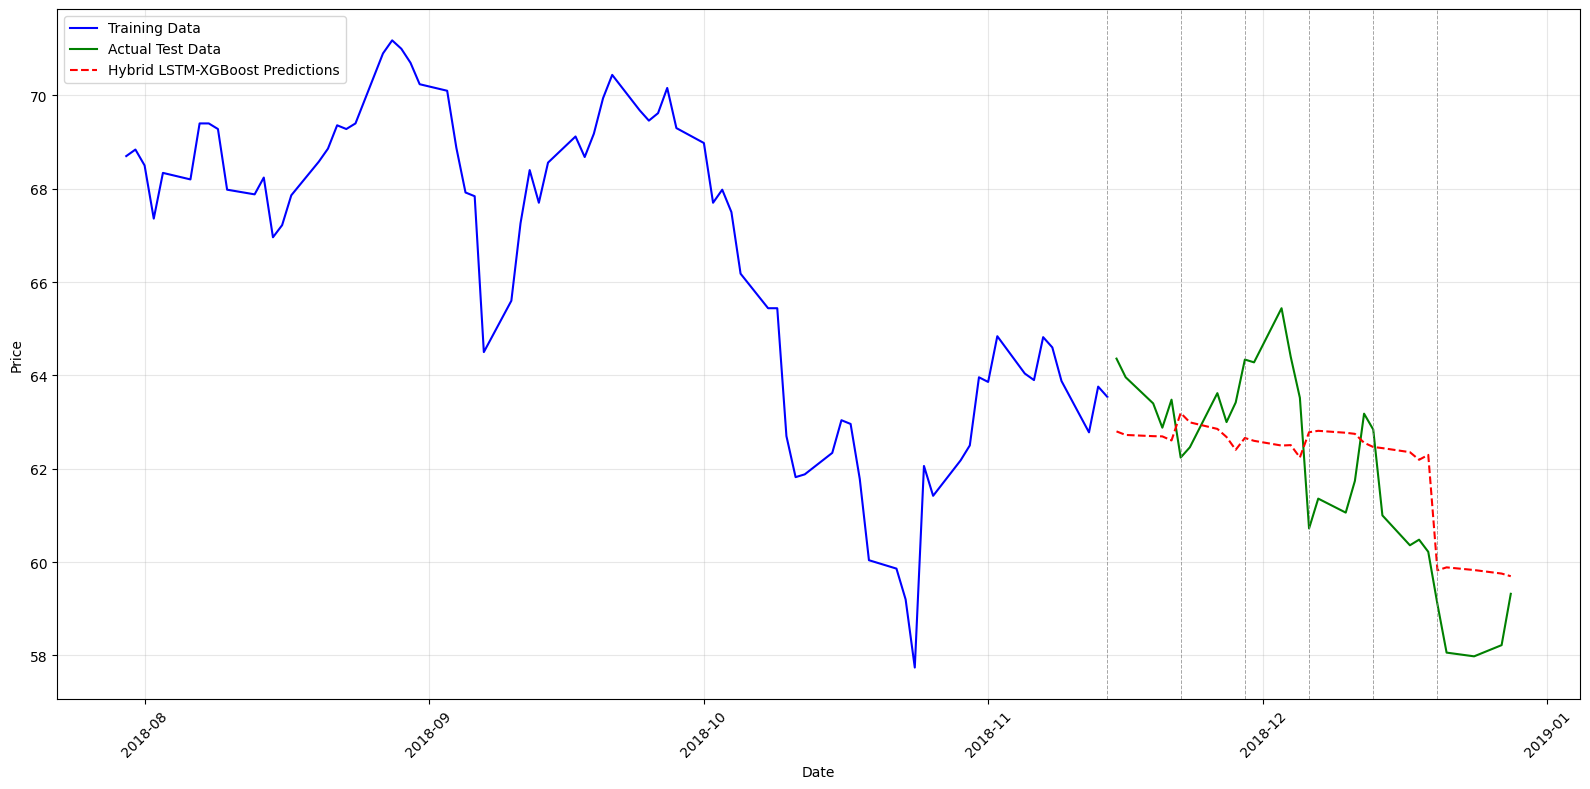

In [9]:
# ============================================
# 5. VISUALIZATION (LAST 5 MONTHS)
# ============================================

print("\n" + "=" * 60)
print("VISUALIZATION")
print("=" * 60)

# Determine date range for last 5 months
end_date_plot = test_series.index.max()
start_date_plot = end_date_plot - pd.DateOffset(months=5)

# Filter data for plotting
train_data_plot = train_series[train_series.index >= start_date_plot]
actual_test_data_plot = test_series[test_series.index >= start_date_plot]
predicted_data_plot = comparison_df[comparison_df.index >= start_date_plot]

# Create plot
plt.figure(figsize=(16, 8))

# Plot training data
plt.plot(train_data_plot.index, train_data_plot.values, 
         label='Training Data', color='blue', linewidth=1.5)

# Plot actual test data
plt.plot(actual_test_data_plot.index, actual_test_data_plot.values, 
         label='Actual Test Data', color='green', linewidth=1.5)

# Plot ensemble predictions
plt.plot(predicted_data_plot.index, predicted_data_plot['LSTM_XGBoost_Predicted'], 
         label='Hybrid LSTM-XGBoost Predictions', color='red', linestyle='--', linewidth=1.5)

# Add vertical line for train-test split
plt.axvline(x=train_series.index[-1], color='gray', 
            linestyle='--', linewidth=0.7, alpha=0.7)

# Add block boundaries (assuming 5-day blocks as before)
n_future_steps_per_block_val = 5
num_test_blocks = len(test_series) // n_future_steps_per_block_val
for i in range(1, num_test_blocks):
    if i * n_future_steps_per_block_val < len(test_series):
        block_boundary = test_series.index[i * n_future_steps_per_block_val]
        plt.axvline(x=block_boundary, color='gray', linestyle='--', 
                    alpha=0.7, linewidth=0.7)

plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

In [10]:
# ============================================
# 6. FINAL SUMMARY
# ============================================

print("\n" + "=" * 60)
print("ENSEMBLE MODEL CREATION COMPLETE")
print("=" * 60)
print(f"Files created:")
print(f"  1. {output_filename} - Contains ensemble predictions")
print(f"\nModel Strategy:")
print(f"  - Simple average of LSTM and XGBoost predictions")
print(f"  - No retraining, uses existing model outputs")
print(f"  - Ensemble size: {len(comparison_df)} prediction days")
print(f"\nPerformance Metrics:")
print(f"  - Ensemble RMSE: {ensemble_rmse:.2f}")
print(f"  - Ensemble MAE:  {ensemble_mae:.2f}")


ENSEMBLE MODEL CREATION COMPLETE
Files created:
  1. lstm_xgboost.csv - Contains ensemble predictions

Model Strategy:
  - Simple average of LSTM and XGBoost predictions
  - No retraining, uses existing model outputs
  - Ensemble size: 30 prediction days

Performance Metrics:
  - Ensemble RMSE: 1.43
  - Ensemble MAE:  1.28
